# Store Sales - Time Series Forecasting

Kaggle competition (https://www.kaggle.com/competitions/store-sales-time-series-forecasting/data) predicting sales for Favorita stores in Ecuador.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression

# set matplotlib defaults
plt.style.use('seaborn-v0_8-whitegrid')
plt.rc('figure', autolayout=True, figsize=(11, 4))
plt.rc('axes',
       labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=14, titlepad=10)
plot_params = dict(color='0.75', style='.-',
                   markeredgecolor='0.25', markerfacecolor='0.25',
                   legend=False)
%config InlineBackend.figure_format = 'retina'

dtype = {'store_nbr': 'category',
         'family': 'category',
         'sales': 'float32',
         'onpromotion': 'uint64'}

# load training data
store_sales = pd.read_csv('data/train.csv', dtype=dtype, parse_dates=['date'])
store_sales.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [2]:
# set index to Period Index
store_sales = store_sales.set_index('date').to_period('D')
store_sales.head()

,id,store_nbr,family,sales,onpromotion
date,,,,,
2013-01-01,0,1,AUTOMOTIVE,0.0,0
2013-01-01,1,1,BABY CARE,0.0,0
2013-01-01,2,1,BEAUTY,0.0,0
2013-01-01,3,1,BEVERAGES,0.0,0
2013-01-01,4,1,BOOKS,0.0,0


In [3]:
# create sub-indices based on store and product family
store_sales = store_sales.set_index(['store_nbr', 'family'], append=True)
store_sales.head()

id  sales  onpromotion
date       store_nbr family                            
2013-01-01 1         AUTOMOTIVE   0    0.0            0
                     BABY CARE    1    0.0            0
                     BEAUTY       2    0.0            0
                     BEVERAGES    3    0.0            0
                     BOOKS        4    0.0            0

In [4]:
# find the average sales for a given date across all stores
average_sales = store_sales.groupby('date').mean()['sales']

## Create linear regression model with a time-step feature

Text(0.5, 1.0, 'Time Plot of Total Store Sales')

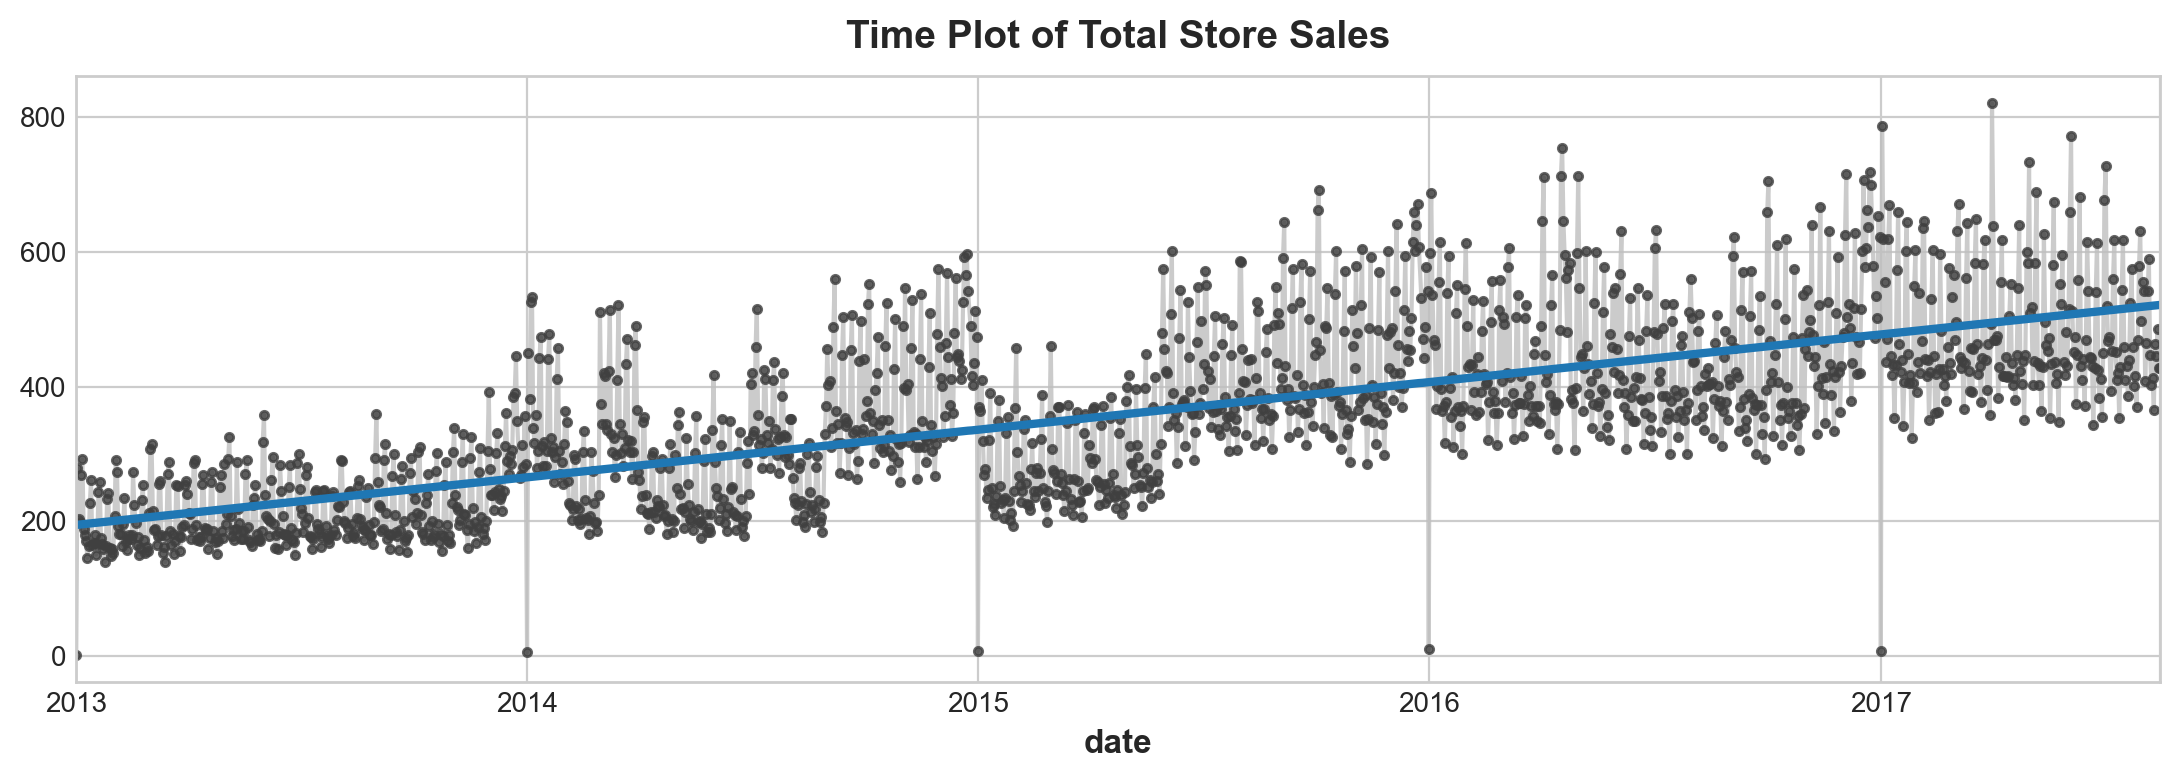

In [5]:
from sklearn.linear_model import LinearRegression

df = average_sales.to_frame()

# create a time dummy
time = np.arange(len(df.index))
df['time'] = time

# organize training data
X = df.loc[:, ['time']] # features; type = DataFrame
y = df.loc[:, 'sales'] # target; type = Series

# train linear regression model
model = LinearRegression()
model.fit(X, y)

# index predicted values with the same time index as training data
y_pred = pd.Series(model.predict(X), index=X.index)

# plot store sales
ax = y.plot(**plot_params, alpha=0.8)
ax = y_pred.plot(ax=ax, linewidth=3)
ax.set_title('Time Plot of Total Store Sales')

## Create linear regression model with a lag feature

In [6]:
# create 1-day shift lag feature & add to dataframe
lag_1 = df['sales'].shift(1)
df['lag_1'] = lag_1

X = df.loc[:, ['lag_1']].dropna() # features; drop null
y = df.loc[:, 'sales'] # target
y, X = y.align(X, join='inner') # drop the corresponding values in target (works since they have the same indexing)

# train linear regression model
model = LinearRegression()
model.fit(X, y)

# index predicted values with the same time index as training data
y_pred = pd.Series(model.predict(X), index=X.index)

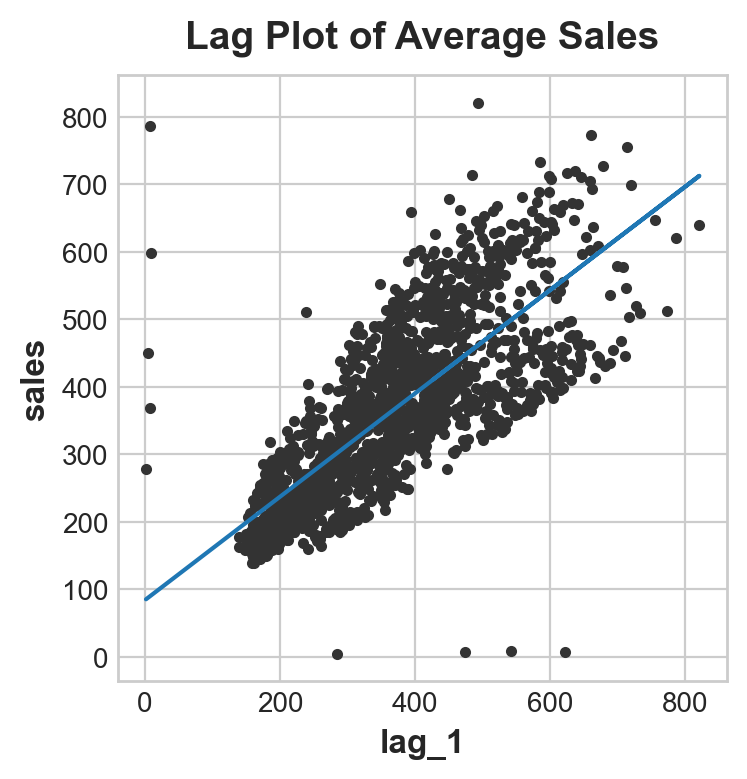

In [7]:
fig, ax = plt.subplots()
ax.plot(X['lag_1'], y, '.', color='0.2')
ax.plot(X['lag_1'], y_pred)
ax.set(aspect='equal', ylabel='sales', xlabel='lag_1', title='Lag Plot of Average Sales');

## Create trend feature

Plot the rolling average to get an idea of what kind of trend model could represent the data.

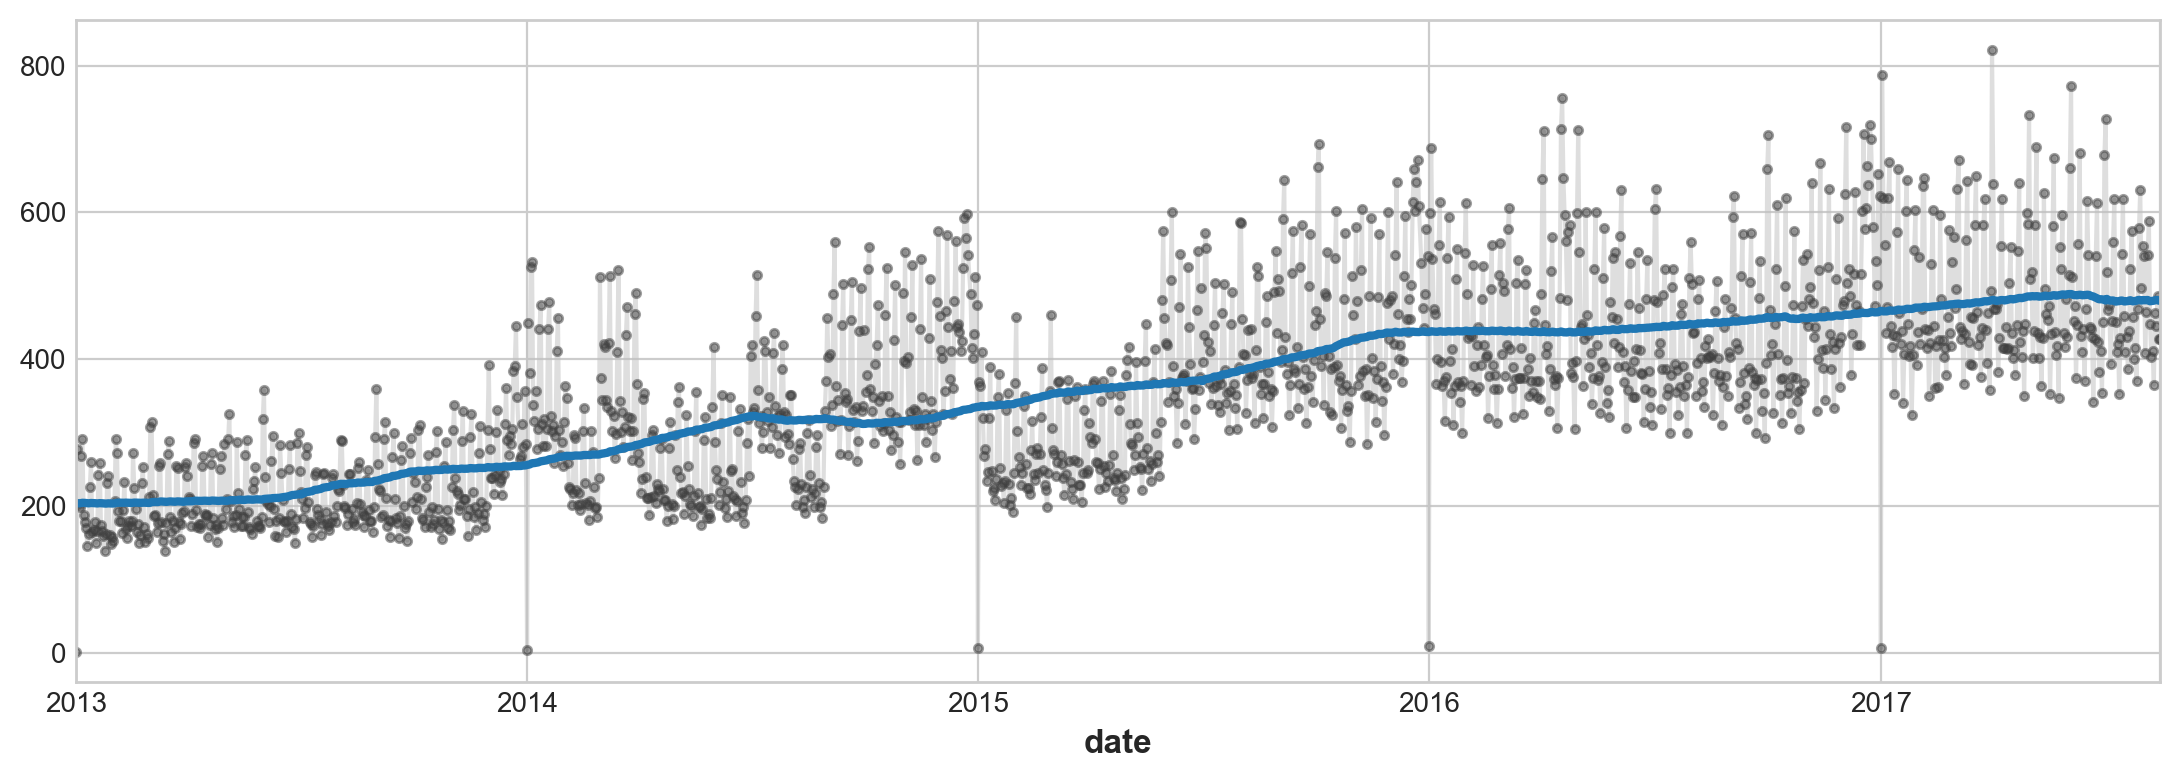

In [11]:
trend = average_sales.rolling(window=365, # 365-day averaging window
                              center=True, # use centre of window
                              min_periods=183, # minimum 183 days for window
                             ).mean()

ax = average_sales.plot(**plot_params, alpha=0.5)
ax = trend.plot(ax=ax, linewidth=3)

In [12]:
from statsmodels.tsa.deterministic import DeterministicProcess

y = average_sales.copy() # target

dp = DeterministicProcess(index=y.index,
                          order=3, # cubic order model
                          drop=True, # drop linearly-dependent terms
                         )

X = dp.in_sample() # features for dates given in index
X.head()

,trend,trend_squared,trend_cubed
date,,,
2013-01-01,1.0,1.0,1.0
2013-01-02,2.0,4.0,8.0
2013-01-03,3.0,9.0,27.0
2013-01-04,4.0,16.0,64.0
2013-01-05,5.0,25.0,125.0


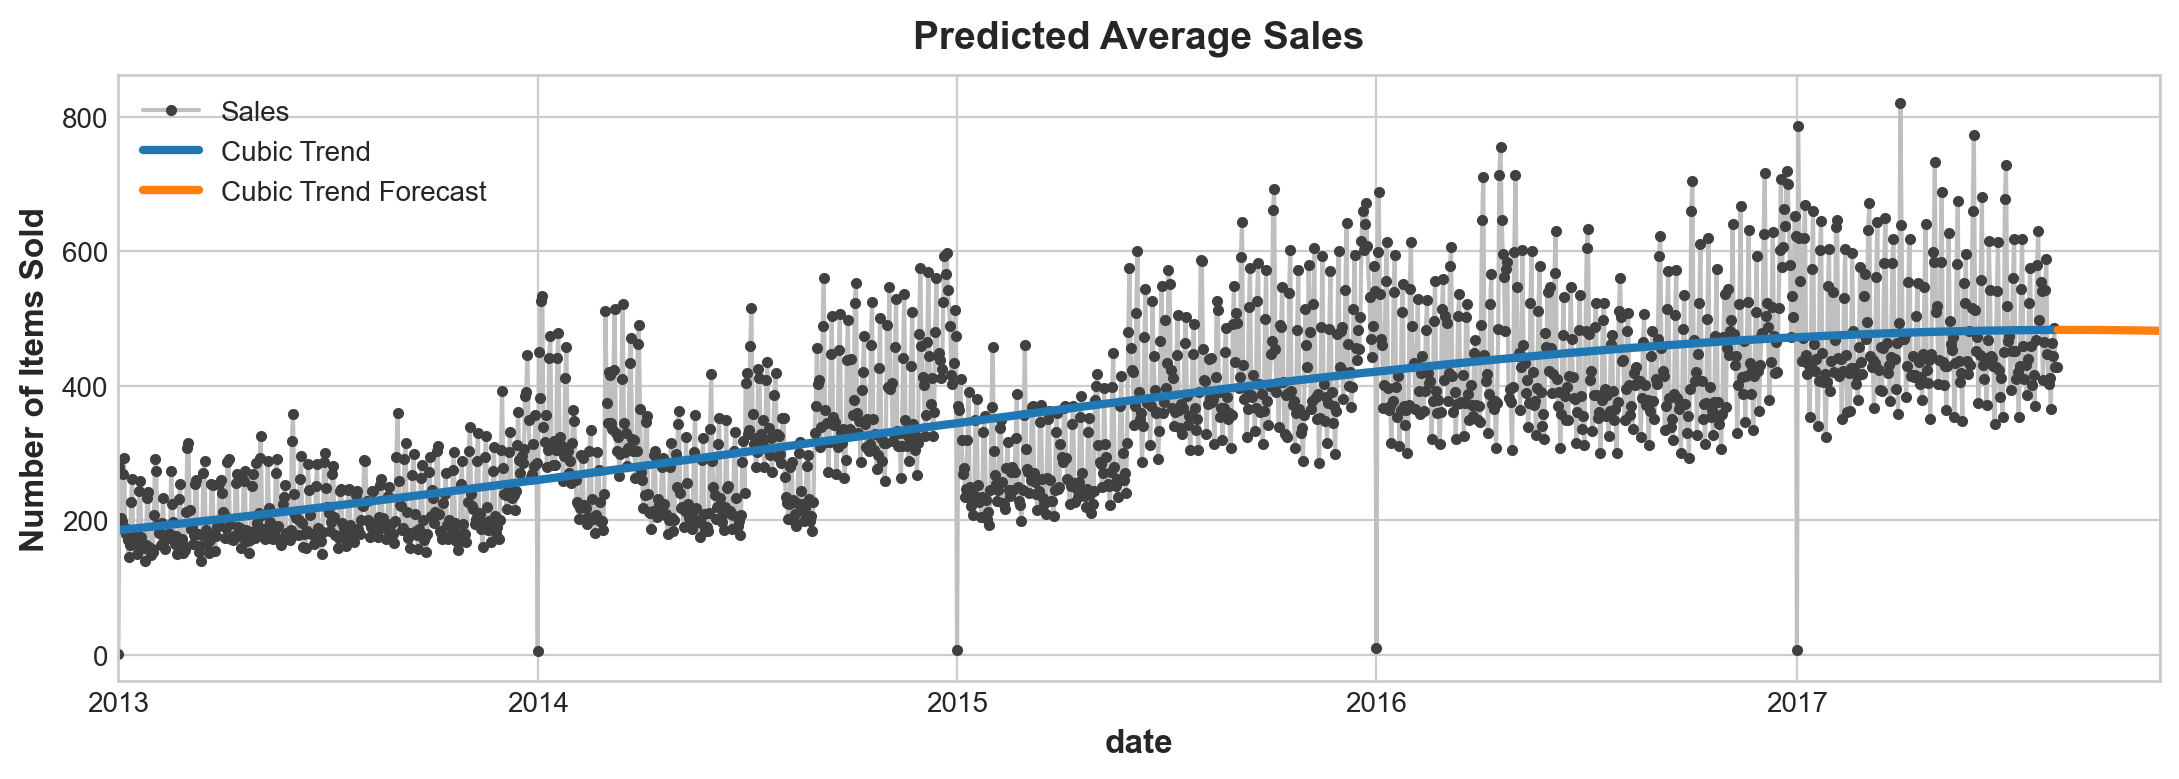

In [20]:
# 90-day forecast:
X_fore = dp.out_of_sample(steps=90)

model = LinearRegression()
model.fit(X,y)

y_pred = pd.Series(model.predict(X), index=X.index)
y_fore = pd.Series(model.predict(X_fore), index=X_fore.index)

ax = y.plot(**plot_params, title='Predicted Average Sales', 
            xlabel='Year', ylabel='Number of Items Sold', label='Sales')
ax = y_pred.plot(ax=ax, linewidth=3, label='Cubic Trend')
ax = y_fore.plot(ax=ax, linewidth=3, label='Cubic Trend Forecast')
ax.legend();

Note that higher-order polynomials tend to overfit the data and are not reliable for out-of-sample forecasting because they can diverge rapidly. See below for 11-th order example.

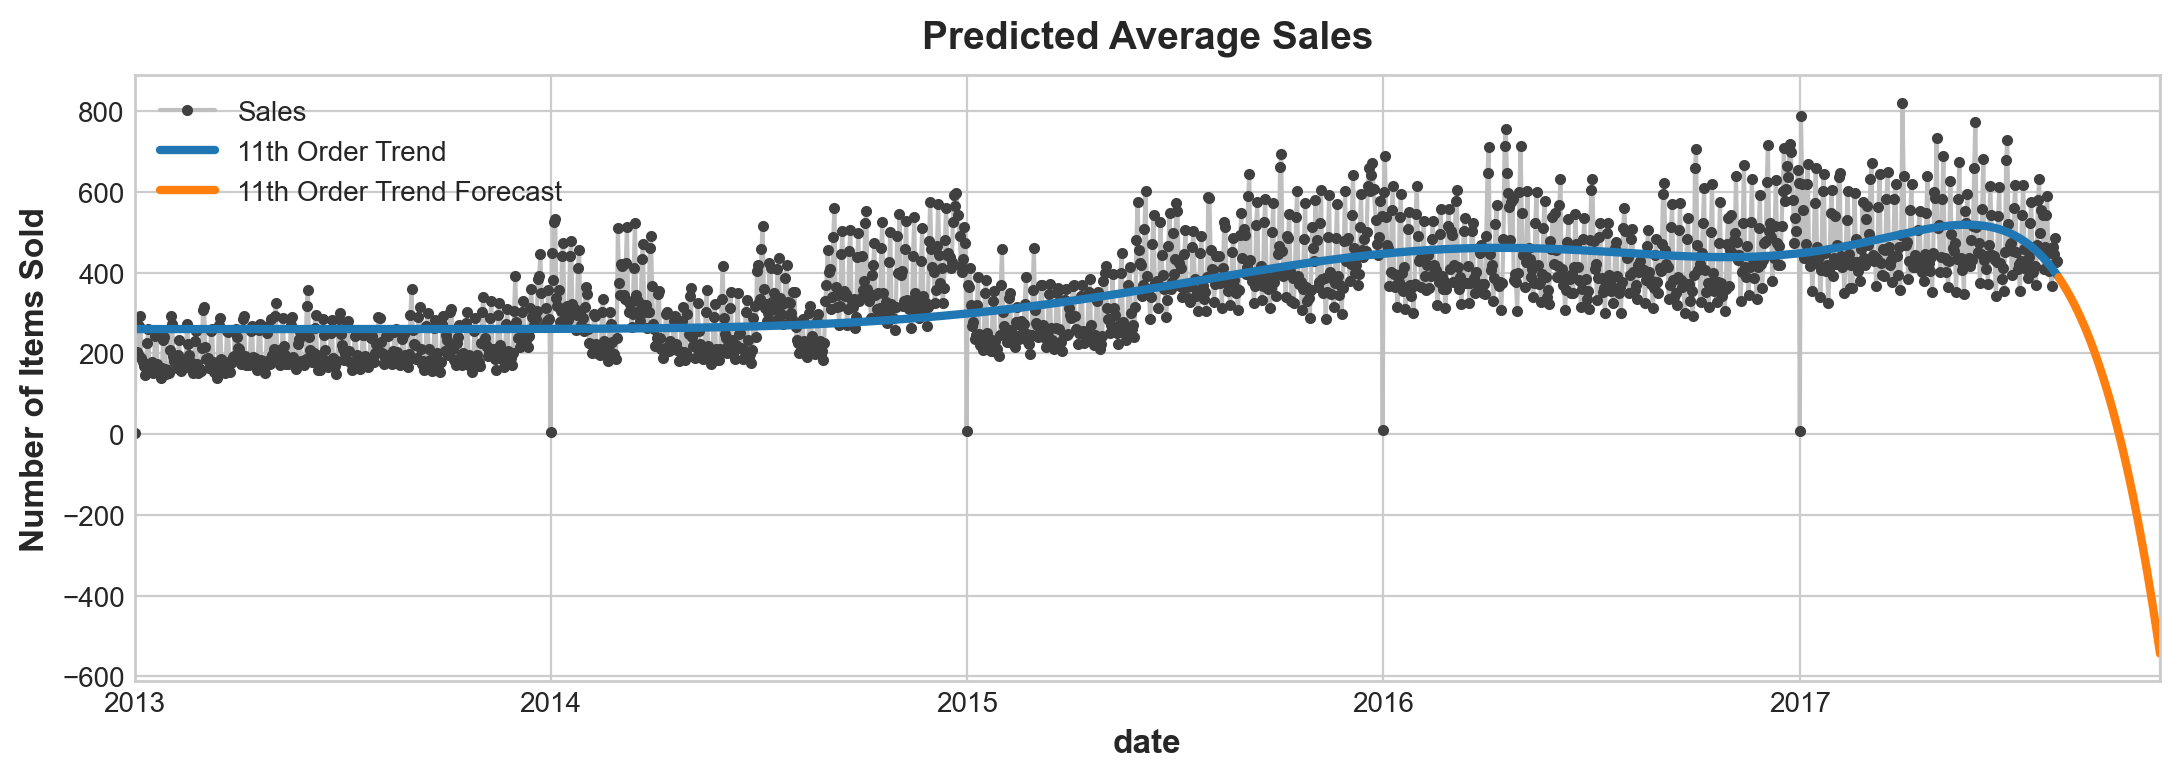

In [42]:
y = average_sales.copy() # target

dp = DeterministicProcess(index=y.index,
                          order=11, # tenth-order model
                         )

X = dp.in_sample() # features for dates given in index
y_pred = pd.Series(model.predict(X), index=X.index)

X_fore = dp.out_of_sample(steps=90)
y_fore = pd.Series(model.predict(X_fore), index=X_fore.index)

ax = y.plot(**plot_params, title='Predicted Average Sales', 
            xlabel='Year', ylabel='Number of Items Sold', label='Sales')
ax = y_pred.plot(ax=ax, linewidth=3, label='11th Order Trend')
ax = y_fore.plot(ax=ax, linewidth=3, label='11th Order Trend Forecast')
ax.legend();